In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as p9

### ATMi
Source: 
https://doi.org/10.1016/j.celrep.2020.01.052, `mmc2` file

In [4]:
# Sheet names: A549, H460, CP0041_20170705_compat_chip
d1 = pd.read_excel('gold_standard_screens_ATMi.xlsx', sheet_name='A549', index_col=0)
d2 = pd.read_excel('gold_standard_screens_ATMi.xlsx', sheet_name='H460', index_col=0)
ann = pd.read_excel('gold_standard_screens_ATMi.xlsx', sheet_name='CP0041_20170705_compat_chip', index_col=0)

In [21]:
df = pd.concat([
    d1.loc[ann.index,:], 
    d2.loc[ann.index,:],
    ann[['Annotated Gene Symbol']]], axis=1)
df.columns = [
    'A549::log2FC:ATMi_vs_DMSO',
    'H460::log2FC:ATMi_vs_DMSO',
    'gene_name'
]
df.set_index('gene_name', inplace=True)

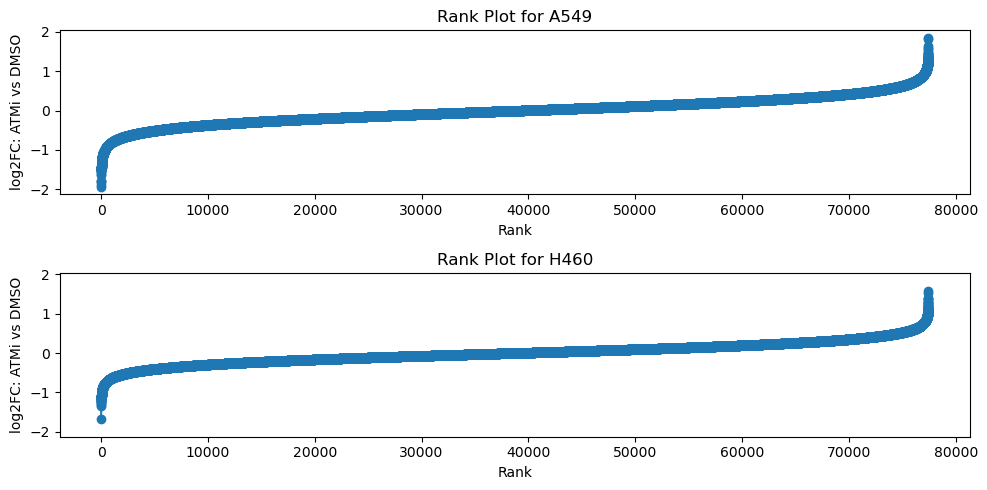

In [30]:
# draw rank plots for each cell line

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharey=True)

# 1. A549
df_sorted = df.sort_values('A549::log2FC:ATMi_vs_DMSO')

# rank plot
axes[0].plot(range(len(df_sorted)), df_sorted['A549::log2FC:ATMi_vs_DMSO'], marker='o')
axes[0].set_title('Rank Plot for A549')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('log2FC: ATMi vs DMSO')

# 2. H460
df_sorted = df.sort_values('H460::log2FC:ATMi_vs_DMSO')
# rank plot
axes[1].plot(range(len(df_sorted)), df_sorted['H460::log2FC:ATMi_vs_DMSO'], marker='o')
axes[1].set_title('Rank Plot for H460')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('log2FC: ATMi vs DMSO')

plt.tight_layout()
plt.show()

let's focus on A549 cell line as it's same model system as in our experiments.

In [77]:
# rank plots for A549 only with highlighted genes. 
# Set quantile threshold for positive and negative fold change.
# Show lines for quantile thresholds.
# return the genes that are above or below the thresholds as lists.
q_low = df['A549::log2FC:ATMi_vs_DMSO'].quantile(0.005)
q_high = df['A549::log2FC:ATMi_vs_DMSO'].quantile(0.995)
print(f'Quantile thresholds for A549: low={q_low}, high={q_high}')

Quantile thresholds for A549: low=-0.9705592088077108, high=0.9357413250472302


In [78]:
ATM_sensetizing = df[df['A549::log2FC:ATMi_vs_DMSO'].le(q_low)].index.to_list()
ATM_resistance  = df[df['A549::log2FC:ATMi_vs_DMSO'].ge(q_high)].index.to_list()

# print sizes of the lists
print(f'Number of ATM sensitizing genes: {len(ATM_sensetizing)}')
print(f'Number of ATM resistance genes: {len(ATM_resistance)}')

Number of ATM sensitizing genes: 388
Number of ATM resistance genes: 388


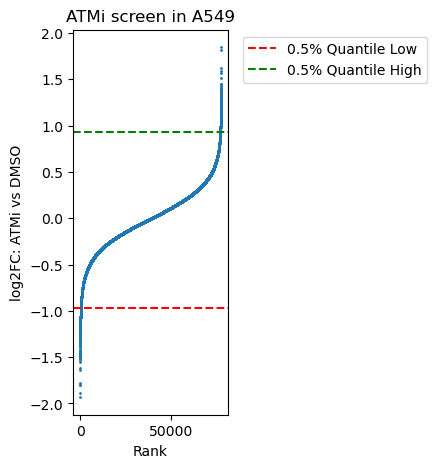

In [84]:
# plot with threshold lines
df_sorted = df.sort_values('A549::log2FC:ATMi_vs_DMSO')
plt.figure(figsize=(2, 5))
plt.plot(range(len(df_sorted)), df_sorted['A549::log2FC:ATMi_vs_DMSO'], marker='o', markersize=1, linestyle='None')
plt.axhline(y=q_low, color='r', linestyle='--', label='0.5% Quantile Low')
plt.axhline(y=q_high, color='g', linestyle='--', label='0.5% Quantile High')
plt.title('ATMi screen in A549')
plt.xlabel('Rank')
plt.ylabel('log2FC: ATMi vs DMSO')
# outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [60]:
# write
with open('ATM_sensitizing_genes.txt', 'w') as f:
    for gene in ATM_sensetizing:
        f.write(f"{gene}\n")

with open('ATM_resistance_genes.txt', 'w') as f:
    for gene in ATM_resistance:
        f.write(f"{gene}\n")